In [1]:
# 第1格：v16新批次；固定本版300概念，逐题接Z-Image作答、GPT-6 xhigh联合评审。
# RUN_PIPELINE=False只加载配置；True通过正式CLI后台提交，前台也使用相同config → run_pipeline。
# 出题、生图、评审最多各300次；失败保留，不替换概念。旧run及其18题、2失败保持历史。
# Codex用原生文件工具读取固定快照，并按需live检索；定义保留，材料不限定考点。
import asyncio
import subprocess
from datetime import datetime, timezone
import json
import os
import sys
from pathlib import Path
from IPython.display import display

PROJECT = Path('/yzp/zhaozy/yangzepeng/0905/demiwtg')
DATA_ROOT = PROJECT.parent
for path in (PROJECT, DATA_ROOT / 'demiflow'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
os.environ['DEMIWTG_DATASETS_ROOT'] = str(DATA_ROOT)
# 本机4001网关已验证无需客户端密钥；平台客户端要求非空值，仅补本地占位，不覆盖已有配置。
os.environ.setdefault('MODELHUB_API_KEY', 'anything')
from benchmark.t2i.v2 import t2i_v2_benchmark_pipeline as pipeline


RUN_ID = 'ready_positive300_common85_codex_v16_probe_20261004'
CONFIG_PATH = PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'config.json'
# 固定来源清单与完整参数保存在同一config.json；CLI --config 和后台执行共用此文件。
PARAMETERS = json.loads(CONFIG_PATH.read_text())
RUN_DIR = Path(PARAMETERS['run'])
CONFIG = pipeline.config(**PARAMETERS)
# 防止共享工作区中的旧prompt覆盖：提交前核对本批约定。
import yaml
AGENT = yaml.safe_load(Path(CONFIG['agent_config']).read_text())
assert AGENT['tasks']['design_question']['version'] == 't2i-v2-independent-materials-16'
assert (CONFIG['model'], CONFIG['reasoning_effort'], CONFIG['codex_web_search']) == ('gpt-6-astra', 'xhigh', 'live')
assert '概念说明中提到的具体特征、实例或任务建议仅供理解，不限定考点或出题方向；请在保留概念身份和必要范围的前提下，按下文质量标准独立设计任务。' in AGENT['tasks']['design_question']['template']
assert CONFIG['max_calls'] == CONFIG['probe']['max_generation_calls'] == CONFIG['probe']['max_review_calls'] == 300
assert AGENT['options']['codex_agent']['max_message_bytes'] is None
import hashlib
LAUNCH_CONTRACT = json.loads((CONFIG_PATH.parent / 'launch_contract.json').read_text())
assert CONFIG['cohort_source'] == LAUNCH_CONTRACT['cohort_source']
assert hashlib.sha256(Path(CONFIG['agent_config']).read_bytes()).hexdigest() == LAUNCH_CONTRACT['authoring_prompt_sha256']
assert hashlib.sha256((PROJECT / 'benchmark/t2i/v2/prompts/tasks.yaml').read_bytes()).hexdigest() == LAUNCH_CONTRACT['review_prompt_sha256']
RUN_PIPELINE = False  # 后台已启动时只运行第2格，避免重复提交。
BACKGROUND = True
print('固定概念来源：', CONFIG['cohort_source'] or CONFIG['concept_audit_source'])
print('固定图审快照：', len(CONFIG['positive_review_sources'] or []))
print('抽样分类摘要：', CONFIG['sampling_taxonomy_source'])
print('Agent配置入口：', CONFIG['agent_config'])
print('Codex模型：', CONFIG['model'], '；推理强度：', CONFIG['reasoning_effort'], '；本轮新会话上限：', CONFIG['max_calls'], '；原生检索：', CONFIG['codex_web_search'])
print('有正例图版300个概念，出题后逐题探测；作答模型只收题面，不收考点、判据或作者正例。')
print('评审：malasci/gpt-6-astra，reasoning_effort=xhigh；一次调用完成考点评审和分类依据。')
print('生图服务需已在配置端点启动；本notebook不自动启动GPU服务。', CONFIG['probe'])
print('Codex内部模型轮数、token和检索次数不受max_calls限制；整会话超时600秒。')
if RUN_PIPELINE:
    if BACKGROUND:
        # 只提交同一个正式CLI；运行锁和模型预算由平台维护，不在notebook另建调度流程。
        PROCESS_PATH = CONFIG_PATH.parent / 'process.json'
        previous = json.loads(PROCESS_PATH.read_text()) if PROCESS_PATH.exists() else {}
        previous_proc = Path('/proc') / str(previous.get('pid', 0))
        if previous_proc.exists() and previous.get('process_start_ticks') == previous_proc.joinpath('stat').read_text().rsplit(')', 1)[1].split()[19]:
            raise RuntimeError(f"本轮后台进程仍在运行：PID {previous['pid']}；请直接运行第2格。")
        CONFIG_PATH.write_text(json.dumps(PARAMETERS, ensure_ascii=False, indent=2) + '\n')
        started = datetime.now(timezone.utc)
        LOG_PATH = CONFIG_PATH.parent / ('probe_' + started.strftime('%Y%m%dT%H%M%SZ') + '.log')
        command = [sys.executable, '-u', '-m', 'benchmark.t2i.v2.t2i_v2_benchmark_pipeline', '--config', str(CONFIG_PATH)]
        with LOG_PATH.open('ab') as output:
            process = subprocess.Popen(command, cwd=PROJECT,
                env={**os.environ, 'PYTHONPATH': os.pathsep.join([str(PROJECT), str(DATA_ROOT / 'demiflow'), os.environ.get('PYTHONPATH', '')])},
                stdin=subprocess.DEVNULL, stdout=output, stderr=subprocess.STDOUT, start_new_session=True)
        receipt = {'pid': process.pid, 'started_at': started.isoformat(), 'config': str(CONFIG_PATH),
                   'log': str(LOG_PATH), 'command': command,
                   'process_start_ticks': Path(f'/proc/{process.pid}/stat').read_text().rsplit(')', 1)[1].split()[19]}
        PROCESS_PATH.write_text(json.dumps(receipt, ensure_ascii=False, indent=2) + '\n')
        display(receipt)
        print('后台已提交；第2格可独立反复运行查看300概念进度、题面、作答图和评审。')
    else:
        state = await asyncio.to_thread(pipeline.run_pipeline, CONFIG)
        display(state)
else:
    print('本格未提交新任务；第2格可独立查看后台进度、已返回题目及已提交结果。')

# 300个名单修订：第一类目标100，当前先纳入全部至少1张正例的85项，优先替换纯第3类。
# 名单修订run只提交输入；上面的RUN_ID提交这份固定300名单的完整探测。
SELECTION_RUN_ID = 'ready_positive300_common100_priority_20261004'
SELECTION_CONFIG_PATH = PROJECT / 'benchmark/t2i/v2/runs' / SELECTION_RUN_ID / 'config.json'
REBUILD_COHORT = False
SELECTION_PARAMETERS = json.loads(SELECTION_CONFIG_PATH.read_text())
SELECTION_CONFIG = pipeline.config(**SELECTION_PARAMETERS)
assert SELECTION_CONFIG['through'] == 'inputs'
display({'300概念名单配置':str(SELECTION_CONFIG_PATH), '修订策略':SELECTION_CONFIG['cohort_revision']})
if REBUILD_COHORT:
    COHORT_STATE = pipeline.run_pipeline(SELECTION_CONFIG)
    display({'已提交名单':COHORT_STATE['inputs'], '替换结果':COHORT_STATE['selection']['revision']})


固定概念来源： {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_common100_priority_20261004.lance', 'version': 4}
固定图审快照： 0
抽样分类摘要： None
Agent配置入口： /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/prompts/agent_codex.yaml
Codex模型： gpt-6-astra ；推理强度： xhigh ；本轮新会话上限： 300 ；原生检索： live
有正例图版300个概念，出题后逐题探测；作答模型只收题面，不收考点、判据或作者正例。
评审：malasci/gpt-6-astra，reasoning_effort=xhigh；一次调用完成考点评审和分类依据。
生图服务需已在配置端点启动；本notebook不自动启动GPU服务。 {'model': 'Z-Image-Turbo', 'endpoints': ['http://127.0.0.1:8003/v1', 'http://127.0.0.1:8004/v1'], 'image_size': '1024x1024', 'steps': 8, 'run_seed': 20261003, 'concurrency': 2, 'queue_depth': 1, 'timeout_s': 600, 'max_image_bytes': 33554432, 'max_generation_calls': 300, 'review_concurrency': 2, 'review_queue_depth': 1, 'max_review_calls': 300, 'review_timeout_s': 600, 'review_max_output_tokens': 8192, 'review_max_context_chars': 60000, 'revision': 'zimage-turbo-fullgpu-dp2-8steps-guidance1-v1'}
Codex内部模型轮数、token和检索次数不受max_call

{'pid': 24209,
 'started_at': '2026-10-03T18:37:34.356499+00:00',
 'config': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/runs/ready_positive300_common85_codex_v16_probe_20261004/config.json',
 'log': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/runs/ready_positive300_common85_codex_v16_probe_20261004/probe_20261003T183734Z.log',
 'command': ['/yzp/zhaozy/yangzepeng/0905/env/bin/python',
  '-u',
  '-m',
  'benchmark.t2i.v2.t2i_v2_benchmark_pipeline',
  '--config',
  '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/runs/ready_positive300_common85_codex_v16_probe_20261004/config.json'],
 'process_start_ticks': '1669234383'}

后台已提交；第2格可独立反复运行查看300概念进度、题面、作答图和评审。


{'300概念名单配置': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/runs/ready_positive300_common100_priority_20261004/config.json',
 '修订策略': {'base_cohort': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_taxonomyv8_codex_ab_20261003.lance',
   'version': 1},
  'case_category_sources': [{'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/case_annotation/datasets/classifications__case_annotation_high_l3_random7000_joint_v1_20260929.lance',
    'version': 1,
    'kind': 'classifications'},
   {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/case_annotation/datasets/adjudications__case_annotation_review_v2_20260929.lance',
    'version': 1,
    'kind': 'adjudications'}],
  'common_limit': 100,
  'min_common_positive_images': 1,
  'common_allow_unassigned_taxonomy': True,
  'image_exclusions': [{'sha256': 'a23dcdeac57ab5af99493054754e05f18a3455b65a9f5ff8f58057e5114ce0e2',
    'reason': '镰刀：PNG 11785x11769，无法在解码前降采样，超过2400万像

**300个名单已修订**：第一类目标 100 个，实际 85 个；新增 59 个，替换 59 个。下方展示本300项的实时出题、作答和评审。

{'新名单固定版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/cohort__ready_positive300_common100_priority_20261004.lance',
  'version': 4},
 '分类挂载待补': ['禁止停车黄网线'],
 '第一类正例下限': 1,
 '待补至目标': 15,
 '技术原因排除的参考图': [{'reason': '镰刀：PNG 11785x11769，无法在解码前降采样，超过2400万像素；只从本轮作者参考图池排除，原审核及图片对象保留。',
   'sha256': 'a23dcdeac57ab5af99493054754e05f18a3455b65a9f5ff8f58057e5114ce0e2'},
  {'reason': '月亮：PNG 5425x5481，无法在解码前降采样，超过2400万像素；全量启动预检发现，仅替换作者参考图，概念及原图审保留。',
   'sha256': '349cbb0652822ec68b9d0844ceb3c9c08f6a87199c9782ef13b578931aa9eb0f'}]}

,概念数
原分类,
1,82
1 / 2,2
1 / 3,1
2,212
2 / 3,1
3,2


,selection_rank,concept,原分类,positive_image_count,sampling_category
16,1,摩天大楼上的午餐,2,5,摄影活动与影像
105,2,斗兽棋棋盘,1,8,游戏棋盘与盘面
36,3,泰坦尼克号遗址,2,5,沉船遗址
173,4,爱（罗伯特·印第安纳）,2,8,视觉艺术与图像设计
293,5,老虎栖息地,2,6,生物栖息环境
30,6,那达慕大会,1,9,文化体系与传统
299,7,特洛伊战争传说,1,5,历史与神话叙事
56,8,奥西里斯,2,8,人物、角色与外观
222,9,六股辫,3,5,辫状编织结构
27,10,贴头辫,2,5,发型与造型技法


原第一类范围 **169**；概念审核通过可出题 **104**；至少1张正例 **85**；至少5张 **50**。正例按相同审定、审核match且aligned、SHA去重、冲突排除统计；原分类冲突保留。

...

### 提供5张作者正例图

状态：**candidate**；

**题面：** 请将1932年的历史摄影作品《摩天大楼上的午餐》（Lunch atop a Skyscraper）重新演绎为一幅黑白插画，准确保留原作的核心人物群像与午餐情境。完整展示人物，并清楚呈现他们与施工结构、下方城市之间的空间关系。

,考点,依据,可观察判据
0,特定作品的十一人群像及共同坐梁关系,洛克菲勒中心官方文章明确介绍，这件作品表现十一名铁工坐在高空钢梁上吃午餐，而非泛指楼顶用餐。[The Builders of NYC](https://www.rockefellercenter.com/magazine/arts-culture/the-builders-of-nyc)。正例图2可见人物沿同一根钢梁并排而坐，腿脚垂到梁下，支持这一核心关系的可观察性。,主体应为十一名可分别辨认的成年男性工人，沿同一根近水平钢梁坐成一排；钢梁直接承托人物，腿脚伸到梁下。人数增减、人物站在梁上或分散坐在不同楼层，均改变原作的核心群像。无需逐人复制脸貌、手势或帽子款式；遮挡导致无法数清时，属于证据不足。
1,日常午餐活动与高空施工位置的结合,审定材料E3所列维基百科的在线Description章节说明，画面表现铁工在曼哈顿RCA大楼施工期间，坐于距地面约260米的钢梁上吃午餐；此处核验使用在线正文。[Lunch atop a Skyscraper](https://en.wikipedia.org/wiki/Lunch_atop_a_Skyscraper#Description)。正例图2可见人物手边的午餐容器，以及显著低于钢梁的城市屋顶，支持活动与高度关系的视觉判定。,部分人物手中或膝上应有可辨认的食物、饭盒或午餐包装，并呈现用餐、交谈或休息的自然状态；城市楼群应明显位于人物下方，通过俯见屋顶及街区形成高空感。只有工人列队而无午餐线索，或将人物画在与街道接近同一高度的位置，均不符合核心情境。无需人人同时进食，不要求复刻具体楼宇、吊索位置或精确高度。


**Z-Image 作答：** generated 

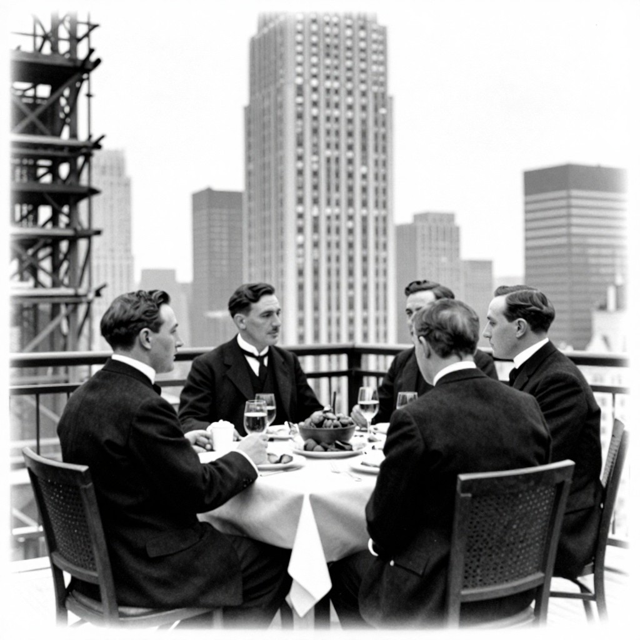

{'task_id': 't2i_37b6b4b10fb7b49a26d74301b3858b66b9314b89a31f021122dccd5fb0243545',
 '生成模型': 'Z-Image-Turbo',
 'seed': 49998938,
 '图像SHA': '767cc4302dc1a968a69c8820562c89b5b607c509c71af1612a04ce4c6f321367'}

**GPT-6 评审：** reviewed 

{'结论': 'fail',
 '分数（-1=不评分）': 2,
 '原因': '画面将核心群像改成五名西装男子围桌就餐，没有十一名工人并排坐在同一钢梁上的关系。虽有明确餐食及城市背景，但呈现的是带护栏的露台餐叙，未建立原作悬空钢梁与下方城市的核心空间关系。',
 '依据': '依据该作品可确认的核心内容：十一名工人并坐高空钢梁，腿脚垂下，在城市上方午餐。两项判据均适用于题面指定的原作重新演绎，不要求复刻面貌或具体建筑；未实际访问所列链接，也不以未提供的参考图作为证据。',
 '错误类型': 'structure_config',
 '本轮评审建议类别': 2}

,考点编号,判断,像素证据,理由
0,1,fail,主体区域可辨认五名穿西装的成年男子，围绕铺白桌布的餐桌坐在有椅背的椅子上；画面中没有承托这一群人的横向钢梁，也没有一排垂到钢梁下的腿脚。左侧施工框架位于人物之外。,实际呈现的是五人围桌坐椅，而非十一名工人共同坐梁；人数和承托关系均有明确冲突，并非因遮挡而无法数清原定群像。
1,2,fail,画面下半部餐桌上有餐盘、食物、杯具，人物呈交谈就餐状态；人物身后为露台护栏，城市建筑主要以正面立面呈现，没有从人物所在钢梁俯视下方屋顶和街区的空间关系。,午餐线索成立，但用餐发生在设桌椅和护栏的露台上，替代了题目要求的高空钢梁施工午餐情境。背景高楼本身不足以建立城市显著位于人物下方的关系；这不等于断言露台接近地面。


{'knowledge_level': 'direct_reference',
 'common_cn': 'uncertain',
 'visual_support': 'strong',
 'confidence': 'high',
 'reason': '这件特定摄影作品的十一人横排坐梁、垂腿午餐及下方城市关系可通过一份明确原作图示直接核对，不涉及专业内部结构或细粒度技术鉴别。其画面具有传播度，但中文大众是否熟悉该作品名称及准确群像细节难以确定。',
 'caveat': '插画风格、人物脸貌、帽子、手势及具体楼宇可有变化；应保留指定作品的核心人数、坐梁关系与高空午餐情境。',
 'sources': []}

{'生成固定快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_generations__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 56},
 '评审快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_reviews__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 300}}

{'runtime': 'codex',
 '记录轮次或会话数': 1,
 '算子观察数': 0,
 '结果版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/designs__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 301},
 '复用': False}

{'原生检索次数': 2,
 '完整会话日志': {'journal_path': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/calls__ready_positive300_common85_codex_v16_probe_20261004.sqlite',
  'request_id': 'a920b09ae37d51c6d86b1f3489b8ae90a503fd54d454e1279f387d363d4b8d37',
  'kind': 'response'}}

### 固定名单绑定的作者正例（实际发送是否成功见设计状态）

作者正例图 1 · SHA `ca889294393a`

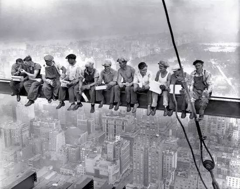

作者正例图 2 · SHA `58a4cb065530`

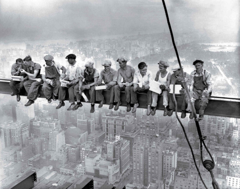

作者正例图 3 · SHA `a2f2843107b6`

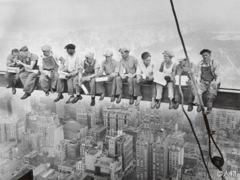

作者正例图 4 · SHA `fc3132e55ec6`

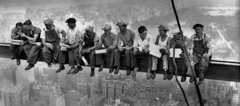

作者正例图 5 · SHA `45a0dff9ae2a`

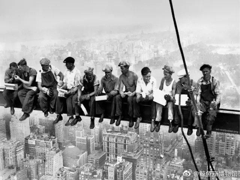

## 2. 斗兽棋棋盘
分类桶：游戏棋盘与盘面；审核正例：8 张

**原概念分类：** 1 · 常见但容易错

定义：斗兽棋棋盘是斗兽棋用于安排棋子格位和特殊区域的对局盘面，以及承载该盘面的棋盘器具；它不是动物棋子的集合，也不等同于包含棋盘和棋子的整套游戏器具。已读材料介绍了九行七列的基本棋盘，同时记载了可能使用九行九列棋盘的变体，因此原名称本身不限定为唯一版本。

### 提供5张作者正例图

状态：**candidate**；

**题面：** 生成一张传统九行七列版斗兽棋空棋盘的正俯视图，不放棋子。完整展示盘面，格位边界清晰，河流、兽穴和陷阱的位置及类型明确可辨，可直接用作对局盘面。

,考点,依据,可观察判据
0,中央河区的范围及其与陆地通路的空间关系,审定材料 E2 所列来源[《鬥獸棋》“棋具”在线正文](https://zh.wikipedia.org/wiki/%E9%AC%A5%E7%8D%B8%E6%A3%8B)记载：棋盘横7列、纵9行，中央有两个2×3格的长方形河区。补充采用的概念知识：传统布局中两河左右并列，位于中央三行，中间及左右边缘各保留一列陆地通路。,以顶部为第1行、左侧为第1列：棋盘应为9行7列，两块河区分别占第4—6行的第2—3列和第5—6列；第1、4、7列在这三行内均为陆地。把河流连成横贯全盘的一条水带、改变河区占格范围或阻断中央陆路，均属实质错误。水域内部可采用连续纹理，但其占格范围必须能从相邻网格判断；颜色与装饰不限。
1,双方兽穴与三个相邻陷阱的对应布局,审定材料 E2 所列来源[《鬥獸棋》“棋具”在线正文](https://zh.wikipedia.org/wiki/%E9%AC%A5%E7%8D%B8%E6%A3%8B)明确记载：双方底行正中各有一个兽穴，兽穴的前、左、右相邻位置分别设陷阱。此处“前”指各自朝向棋盘中央的一侧，适用于题面限定的传统九行七列版本。,两条七格底边的正中格各有一个兽穴；每个兽穴的左邻格、右邻格和朝向棋盘中央的邻格各有一个陷阱，共两穴六陷阱。兽穴与陷阱须能区分。将陷阱放在兽穴的对角格、漏掉朝内的陷阱、把兽穴放在角落或移入内圈，均属实质错误。具体符号、文字与双方配色可变化；标识无法区分时，不能确认布局正确。


**Z-Image 作答：** generated 

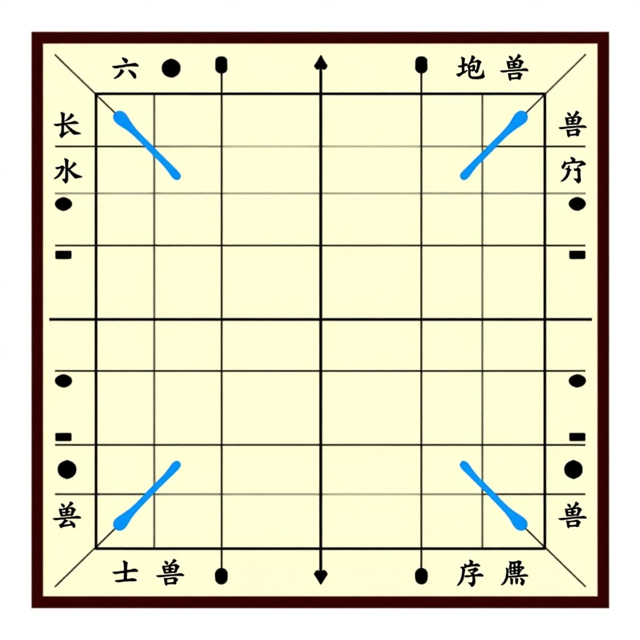

{'task_id': 't2i_78273b73fba827dd97a827814a09b592ce5481e37550a65317f5f20201ea2a9e',
 '生成模型': 'Z-Image-Turbo',
 'seed': 1474725127,
 '图像SHA': '0431721bee5a08f4e2a63052c328325287fc17515c02a39c6892d2ea1e00e98f'}

**GPT-6 评审：** reviewed 

{'结论': 'fail',
 '分数（-1=不评分）': 2,
 '原因': '图中虽有完整的九行七列网格和空棋盘形式，但中央没有可辨认的两块2×3河区，关键河陆关系未成立；兽穴与陷阱也主要表现为棋盘外缘的黑色符号，未能确认位于双方底行及其规定相邻格内。',
 '依据': '按题面限定的传统九行七列斗兽棋布局核对：要求中央第4—6行的两块2×3河区，以及双方底行中央兽穴和其左、右、朝内相邻陷阱。图中网格可见，但上述核心区域和格内标识不符合或无法确认。',
 '错误类型': 'structure_config',
 '本轮评审建议类别': 2}

,考点编号,判断,像素证据,理由
0,1,fail,主棋盘内可见规则九行七列网格；中央第4—6行并未出现分别占第2—3列和第5—6列的两块水域，只有空白陆地格，蓝色斜线位于上、下方边角区域且不构成规定河区。,中央河区的占格范围和两侧陆地通路是该判据的决定性结构，图中没有呈现两块2×3河流，因此与要求冲突。
1,2,fail,图中在棋盘外侧或边框附近可见黑色圆点、短矩形和箭头等符号，但双方底行中央格及其左、右、朝向中央的相邻格内没有清楚可辨的兽穴与三陷阱组合；符号与棋盘格的对应关系也不成立。,判据要求每个底行中央格为兽穴，并在三个正交相邻格设置可区分的陷阱。现有符号主要脱离格内布局，无法满足这一对应关系。


{'knowledge_level': 'direct_reference',
 'common_cn': 'yes',
 'visual_support': 'strong',
 'confidence': 'high',
 'reason': '斗兽棋作为中文语境中的常见棋类名称通常可被大众识别；本题所需的九行七列、河区及兽穴陷阱布局具有明确且可直接对照的平面视觉结构，不需专业内部知识。',
 'caveat': '不同绘制风格、颜色和文字标记可以变化，但传统九行七列版本的核心格位关系不能改变。',
 'sources': []}

{'生成固定快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_generations__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 204},
 '评审快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_reviews__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 300}}

{'runtime': 'codex',
 '记录轮次或会话数': 1,
 '算子观察数': 0,
 '结果版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/designs__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 301},
 '复用': False}

{'原生检索次数': 2,
 '完整会话日志': {'journal_path': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/calls__ready_positive300_common85_codex_v16_probe_20261004.sqlite',
  'request_id': '2d9e21b8e948670a9a18dc1037c4f9793c998cf6af694bb4c8d53849a98c9269',
  'kind': 'response'}}

### 固定名单绑定的作者正例（实际发送是否成功见设计状态）

作者正例图 1 · SHA `19e4d3f50a8a`

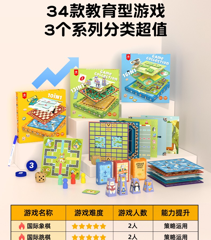

作者正例图 2 · SHA `8b601e815d6d`

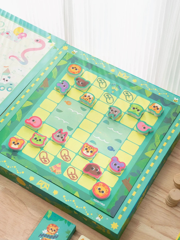

作者正例图 3 · SHA `289be9ffab6a`

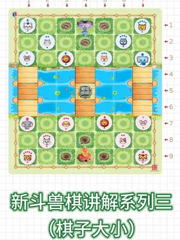

作者正例图 4 · SHA `ec5c0ef0ed9c`

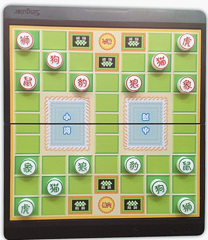

作者正例图 5 · SHA `0d0966be7b52`

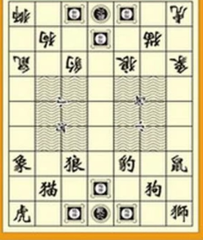

## 3. 泰坦尼克号遗址
分类桶：沉船遗址；审核正例：5 张

**原概念分类：** 2 · 有显著的视觉特征

定义：泰坦尼克号遗址指 RMS Titanic 沉没后形成于北大西洋海底的沉船遗址，包括分离的船首段、船尾段及周围散落的船舶残片和物品。本次按遗存的实体分布理解其范围，不将其等同于单一船体部分，也不据此确定法律保护区域的边界。

### 提供5张作者正例图

状态：**candidate**；

**题面：** 生成一幅泰坦尼克号遗址的斜俯视三维科普示意图，呈现现代海底探测所见的遗存状态。画面应覆盖主要船体遗存及其间和周围的连续海床，清楚展示遗址的组成、空间分布，以及各主要船体部分的保存形态。采用便于辨认的示意照明，使残骸轮廓和破损结构可见。

,考点,依据,可观察判据
0,分离的船首、船尾与散落残片共同构成遗址,审定材料 E3 对应来源 [RMS Titanic Inc.：Titanic Wreck Site](https://rmstitanicinc.com/titanic-wreck/)（本次读取在线正文）记载：船首段与船尾段相距约2000英尺，两者周围分布着广阔的残片区。因此，遗址整体不能等同于单独的船首或连续完整的船体。,船首段和船尾段应分别落在海床上，之间存在明显的海床间隔，主体之外可见散落的船舶结构残片。画成连续船体、仅以一道窄裂缝表示分离，或只画孤立船首而遗漏其余主体，均不符合要求。不要求精确米数、残片数量或每件遗物的位置。
1,船首与船尾保存形态的显著差异,实际查阅的伍兹霍尔海洋研究所 [Titanic in a New Light](https://www.whoi.edu/?visual_whoi_item=titanic-in-a-new-light) 图注说明：船首相较船尾保存较完整，船尾存在严重结构损伤；审定材料 E3 对应在线正文的 The Bow、The Stern 段同样说明船首仍易辨认，船尾则严重扭曲并大幅改变原貌。,船首应保留可辨的尖形首部及较连续的船壳、甲板轮廓，同时体现残损；船尾应明显更为坍塌、扭曲，结构轮廓破碎。把两段画成同样整齐完整的半艘船，或颠倒两者的保存差异，属于实质错误。允许局部破损细节变化；若尺度或遮挡使形态无法辨认，则证据不足。


**Z-Image 作答：** generated 

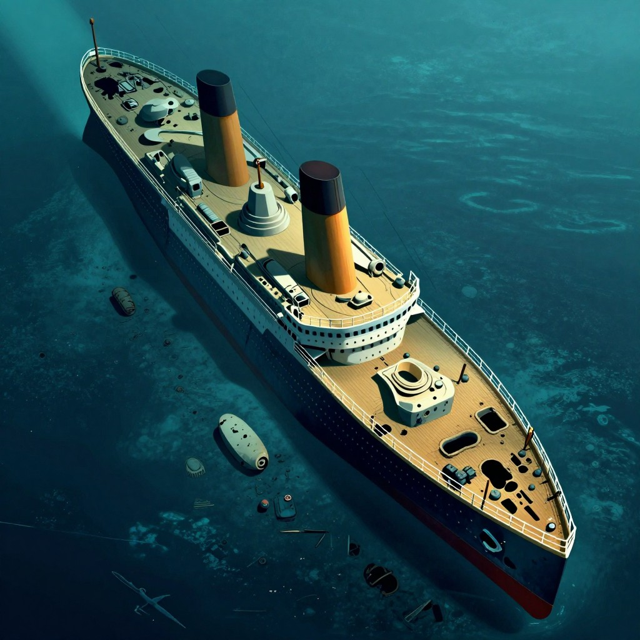

{'task_id': 't2i_685bc9aadfe5dc9edf286f6399b0f6a0521dc7886f2630554a84d7abb9f30019',
 '生成模型': 'Z-Image-Turbo',
 'seed': 230258243,
 '图像SHA': '948b25647848be14e761d098cbd9f96341c1d2a44c2955f11ebe231451ce8055'}

**GPT-6 评审：** reviewed 

{'结论': 'fail',
 '分数（-1=不评分）': 1,
 '原因': '图像主要呈现一艘连续、近乎完整且仍具完整甲板与烟囱的海底船体，没有呈现泰坦尼克号遗址所要求的分离船首、船尾及其间广阔海床残片区。虽然有海底环境和少量散落物，但核心遗址构成与船首/船尾保存差异均未满足。',
 '依据': '依据题面给定的 RMS Titanic Inc. 遗址构成信息及 WHOI 关于船首较完整、船尾严重扭曲的说明评审；不要求精确比例或残片位置，但要求分离的两段船体及显著保存差异。',
 '错误类型': 'structure_config',
 '本轮评审建议类别': 3}

,考点编号,判断,像素证据,理由
0,1,fail,画面中央是一艘从左上延伸至右下的连续完整船体，船首、船尾仍连接在同一艘船上；周围虽有少量零散物体，但没有两个彼此分离的主要船体段，也没有清楚的两段之间海床间隔。,判据要求船首段和船尾段分别落在海床上并由明显海床间隔分开，主体外还应有散落残片共同构成遗址；本图将遗址画成连续船体，因此核心构成不符合。
1,2,fail,图中整艘船的甲板、船壳、烟囱和两端轮廓均较完整，左上端与右下端都没有呈现严重坍塌、扭曲或大幅破碎的独立船尾结构。,判据要求船首保留较连续的尖形轮廓并有残损，同时船尾明显更坍塌扭曲；本图没有分离的船尾可供呈现这种差异，且整体完整状态与要求冲突。


{'knowledge_level': 'specialist',
 'common_cn': 'yes',
 'visual_support': 'strong',
 'confidence': 'high',
 'reason': '“泰坦尼克号”对中文大众较熟悉，但具体遗址状态需要辨认分离的船首、船尾、残片区以及两段不同的保存程度，属于具有明确视觉特征的细粒度鉴别。',
 'caveat': '合法的视角、照明和局部破损细节可以变化，但不能省略遗址的分离布局或将两段恢复为连续完整船体。',
 'sources': ['https://rmstitanicinc.com/titanic-wreck/',
  'https://www.whoi.edu/?visual_whoi_item=titanic-in-a-new-light']}

{'生成固定快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_generations__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 224},
 '评审快照': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/probe_reviews__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 300}}

{'runtime': 'codex',
 '记录轮次或会话数': 1,
 '算子观察数': 0,
 '结果版本': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/designs__ready_positive300_common85_codex_v16_probe_20261004.lance',
  'version': 301},
 '复用': False}

{'原生检索次数': 4,
 '完整会话日志': {'journal_path': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/t2i/v2/datasets/calls__ready_positive300_common85_codex_v16_probe_20261004.sqlite',
  'request_id': '7d03c6c6fdc29f95dd1418b21e435d8630a08d2366580484df750774d19ac80b',
  'kind': 'response'}}

### 固定名单绑定的作者正例（实际发送是否成功见设计状态）

作者正例图 1 · SHA `60980324398b`

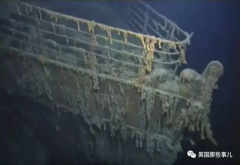

作者正例图 2 · SHA `1fadaafd4bbc`

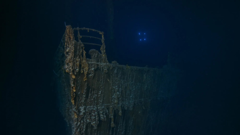

作者正例图 3 · SHA `1febcddc65b5`

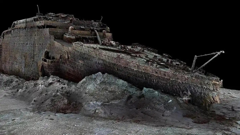

作者正例图 4 · SHA `f9a93c529849`

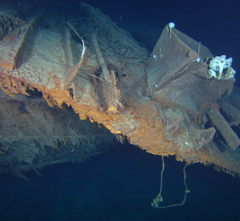

作者正例图 5 · SHA `f0bf41d97273`

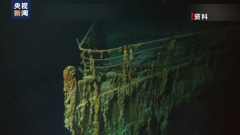

In [1]:
# 第2格：独立只读查看；不依赖第1格，不调用模型、不写业务表。修改PAGE后重跑本格。
import base64
import io
import json
import os
import re
import sys
from html import escape
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import lance
import pandas as pd
pd.set_option('display.max_colwidth', None)
from PIL import Image as PILImage
from IPython.display import display, Markdown, HTML

PROJECT = Path('/yzp/zhaozy/yangzepeng/0905/demiwtg')
DATA_ROOT = PROJECT.parent
for path in (PROJECT, DATA_ROOT / 'demiflow'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
os.environ['DEMIWTG_DATASETS_ROOT'] = str(DATA_ROOT)
from demiflow import data
from demiflow.operator_llm.call_ref import read_call
from demiflow.operator_llm.sqlite_journal import SQLitePromptJournal
from benchmark.t2i.v2.operaters.run_tables import RunTables
from benchmark.t2i.v2.operaters.images import positive_image_data_url

# 独立查看300个新名单及全部169个原第一类概念的审核/正例覆盖；分页只读。
SELECTION_RUN_ID = 'ready_positive300_common100_priority_20261004'
COMMON_PAGE = 0
COMMON_PAGE_SIZE = 20
selection_dir = PROJECT / 'benchmark/t2i/v2/runs' / SELECTION_RUN_ID
selection_state = RunTables(DATA_ROOT, 'demiwtg/benchmark/t2i/v2/datasets/records__' + SELECTION_RUN_ID + '.lance').load()
coverage = json.loads((selection_dir / 'category1_audit.json').read_text())
common_scope = pd.DataFrame(coverage['records'])
selected_names = set()
if selection_state and selection_state.get('inputs'):
    selected_names = {row['concept'] for row in data.read_lance(**selection_state['inputs'], columns=['concept']).take_all()}
    revision = selection_state['selection']['revision']
    display(Markdown(f"**300个名单已修订**：第一类目标 {revision['requested_common_count']} 个，实际 {revision['selected_common_count']} 个；新增 {len(revision['added'])} 个，替换 {len(revision['removed'])} 个。下方展示本300项的实时出题、作答和评审。"))
    display({'新名单固定版本':selection_state['inputs'], '分类挂载待补':revision.get('unassigned_common_taxonomy', []), '第一类正例下限':revision['min_common_positive_images'],
             '待补至目标':revision['requested_common_count'] - revision['selected_common_count'],
             '技术原因排除的参考图':revision.get('image_exclusions', [])})
    pixel_verification_path = selection_dir / 'sampling_verification.json'
    if pixel_verification_path.exists():
        pixel_verification = json.loads(pixel_verification_path.read_text())
        if pixel_verification['cohort'] == selection_state['inputs']:
            display({'已检查参考图关系':pixel_verification['common_reference_relations_checked'],
                     '技术失败':pixel_verification['common_reference_failures']})
    display(HTML('<details><summary>新增与替换的概念</summary><pre>' + escape(json.dumps(
        {'新增':revision['added'], '移出':revision['removed']}, ensure_ascii=False, indent=2)) + '</pre></details>'))
# 300项原分类与正例数量另行分页，不混入下方300项的作答结果。
COHORT_PAGE = 0
COHORT_PAGE_SIZE = 20
if selection_state and selection_state.get('inputs'):
    cohort_table = pd.DataFrame(data.read_lance(**selection_state['inputs'], columns=[
        'concept','selection_rank','positive_image_count','sampling_category']).take_all()).sort_values('selection_rank')
    cohort_labels = {name:set() for name in cohort_table.concept}
    predicate = 'concept IN (' + ','.join("'" + name.replace("'", "''") + "'" for name in cohort_labels) + ')'
    for source in coverage['category_sources']:
        cols = ['concept','final_category'] + (['final_selected'] if source['kind'] == 'adjudications' else [])
        for record in data.read_lance(**source['result'], columns=cols, filter=predicate).take_all():
            if record.get('final_selected', True) and record['final_category'] in ('1','2','3'):
                cohort_labels[record['concept']].add(record['final_category'])
    cohort_table['原分类'] = cohort_table.concept.map(lambda name:' / '.join(sorted(cohort_labels[name])))
    display(cohort_table.groupby('原分类').size().rename('概念数').to_frame())
    assert COHORT_PAGE >= 0 and 1 <= COHORT_PAGE_SIZE <= 100
    display(cohort_table[['selection_rank','concept','原分类','positive_image_count','sampling_category']].iloc[
        COHORT_PAGE * COHORT_PAGE_SIZE:(COHORT_PAGE + 1) * COHORT_PAGE_SIZE])
common_scope['已纳入300'] = common_scope.concept.isin(selected_names)
current_common_names = common_scope.loc[common_scope['已纳入300'], 'concept'].tolist()
display(HTML('<details><summary>本批第一类完整名单（' + str(len(current_common_names)) + '个）</summary><p>' + escape('、'.join(current_common_names)) + '</p></details>'))
common_scope['原分类'] = common_scope.original_categories.map(lambda records: ' / '.join(sorted({r['final_category'] for r in records if r.get('final_selected', True)})))
display(Markdown(f"原第一类范围 **{coverage['scope_count']}**；概念审核通过可出题 **{coverage['ready_count']}**；至少1张正例 **{coverage['ready_at_least_one']}**；至少5张 **{coverage['eligible_count']}**。正例按相同审定、审核match且aligned、SHA去重、冲突排除统计；原分类冲突保留。"))
assert COMMON_PAGE >= 0 and 1 <= COMMON_PAGE_SIZE <= 100
display(common_scope[['concept','原分类','status','identity_status','task_status','positive_image_count','已纳入300']].iloc[
    COMMON_PAGE * COMMON_PAGE_SIZE:(COMMON_PAGE + 1) * COMMON_PAGE_SIZE].rename(columns={
    'concept':'概念','status':'概念审核状态','identity_status':'身份状态','task_status':'出题资格','positive_image_count':'审核正例数'}))

RUN_ID = 'ready_positive300_common85_codex_v16_probe_20261004'
PAGE = 0
PAGE_SIZE = 3
PROGRESS_PAGE = 0
PROGRESS_PAGE_SIZE = 30
LIVE_PAGE = 0  # 已返回响应按请求提交时间倒序分页；与下方固定名单的PAGE独立。
LIVE_PAGE_SIZE = 3
CONCEPT = ''  # 填精确概念名可直接定位；为空时按固定selection_rank分页。
OWNER = Path('demiwtg/benchmark/t2i/v2/datasets')
RUN_CONFIGURATION = json.loads((PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'config.json').read_text())
VARIANTS = RUN_CONFIGURATION.get('authoring_variants') or [RUN_CONFIGURATION['authoring_variant']]
PAIRED = bool(RUN_CONFIGURATION.get('authoring_variants'))
PROCESS_PATH = PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'process.json'
HEALTH_PATH = PROCESS_PATH.parent / 'health.json'
if HEALTH_PATH.exists():
    display({'最近一次健康检查快照（以 checked_at 为准）':json.loads(HEALTH_PATH.read_text())})
CLEANUP_PATH = PROCESS_PATH.parent / 'service_cleanup.json'
if CLEANUP_PATH.exists():
    display({'GPU 服务收尾记录':json.loads(CLEANUP_PATH.read_text())})
if PROCESS_PATH.exists():
    process = json.loads(PROCESS_PATH.read_text())
    proc = Path('/proc') / str(process['pid'])
    alive = proc.exists() and process.get('process_start_ticks') == proc.joinpath('stat').read_text().rsplit(')', 1)[1].split()[19]
    display({'后台进程':process['pid'], '进程仍存在':alive, '启动时间（北京时间）':datetime.fromisoformat(process['started_at']).astimezone(ZoneInfo('Asia/Shanghai')).isoformat(), '日志':process['log']})
    with Path(process['log']).open('rb') as output:
        output.seek(max(0, output.seek(0, 2) - 16000))
        log_tail = output.read().decode('utf-8', errors='replace')
    display(HTML('<details><summary>后台日志末尾（最多16 KB）</summary><pre>' + escape(log_tail) + '</pre></details>'))
state = RunTables(DATA_ROOT, str(OWNER / f'records__{RUN_ID}.lance')).load()
state = state or {'complete':False, 'phase':'not_started'}
COHORT_REF = RUN_CONFIGURATION.get('cohort_source') or state.get('inputs')
# 固定名单与本轮输入分别显示；等待/失败项始终保留在300概念分母里。
display({'刷新时间（北京时间）':datetime.now(ZoneInfo('Asia/Shanghai')).isoformat(),
         '本轮配置':RUN_CONFIGURATION, '本轮已提交输入':state.get('inputs')})
assert PAGE >= 0 and LIVE_PAGE >= 0 and 1 <= PAGE_SIZE <= 20 and 1 <= LIVE_PAGE_SIZE <= 20
if not COHORT_REF:
    display(Markdown('当前运行尚未提交共同输入；旧输出不能作为本轮完成结果。'))
else:
    display(Markdown(f"## 出题运行：{RUN_ID}\n阶段：{state.get('phase')}；全部完成：{state['complete']}。候选题仍待质量审核。"))
    display({'固定概念名单': COHORT_REF})
    narrow = data.read_lance(**COHORT_REF, columns=['concept','selection_rank','positive_image_count','sampling_category']).take_all()
    summary = pd.DataFrame(narrow).sort_values('selection_rank')
    summary['一级分类'] = summary.sampling_category.str.split(' / ').str[0]
    display(summary.groupby('一级分类', sort=True).size().rename('概念数').to_frame())
    display(Markdown(f"共同名单 {len(summary)} 个；最少审核正例 {summary.positive_image_count.min()} 张。按本轮固定分类路径抽样；分类来源和质量状态见下方。"))
    taxonomy = state.get('sources', {}).get('sampling_taxonomy')
    if taxonomy:
        display({'分类版本':taxonomy['summary'], '分类运行':taxonomy['run'],
                 '分类阶段':taxonomy['phase'], '分类质量通过':taxonomy['quality_passed'],
                 '满足图数门槛':state['selection']['ready_with_positive_images'],
                 '因未匹配分类排除':state['selection']['excluded_without_matching_taxonomy']})
        if not taxonomy['quality_passed']:
            display(Markdown('本轮仅以候选分类进行分层抽样，不代表该分类已发布或全部复核通过。'))
    else:
        display(Markdown('沿用固定输入表保存的分类。当前只执行配置中的版本，达到本批概念数后停止。'))
    # 原概念三类来自evaluation/t2i/case_annotation已提交的历史结果；仅只读关联，不进入模型请求。
    from evaluation.t2i.case_annotation.operaters.review import FINAL_CATEGORIES
    CATEGORY_SOURCES_PATH = PROJECT / 'benchmark/t2i/v2/runs' / RUN_ID / 'case_category_sources.json'
    category_sources = json.loads(CATEGORY_SOURCES_PATH.read_text()) if CATEGORY_SOURCES_PATH.exists() else []
    original_categories = {name:[] for name in summary.concept}
    category_predicate = 'concept IN (' + ','.join("'" + name.replace("'", "''") + "'" for name in summary.concept) + ')'
    for category_source in category_sources:
        kind = category_source['kind']
        reason_column = 'classification_reason' if kind == 'classifications' else 'adjudication_reason'
        category_columns = ['concept','id','image_sha256','final_category',reason_column]
        if kind == 'adjudications':
            category_columns.append('final_selected')
        # 按原概念名精确匹配，只读本轮固定300项所需列，历史URI由平台迁移映射解析。
        for category_row in data.read_lance(**category_source['result'], columns=category_columns, filter=category_predicate).take_all():
            category_code = category_row['final_category']
            category_label = FINAL_CATEGORIES.get(category_code, '暂缓归类')
            if category_row.get('final_selected') is False:
                category_label = '原记录未纳入'
            original_categories[category_row['concept']].append({
                '原类别': (str(category_code) + ' · ' if category_code and category_row.get('final_selected') is not False else '') + category_label,
                '来源':category_source['label'], '原归类理由':category_row[reason_column],
                '固定结果':category_source['result'], '固定摘要':category_source['summary'],
                '原case ID':category_row['id'], '原作答图SHA':category_row['image_sha256']})
    original_category_labels = {name:' / '.join(dict.fromkeys(row['原类别'] for row in records)) or '无已配置的原标注'
                                for name, records in original_categories.items()}
    display(Markdown('**原概念分类**：①常见但容易错；②有显著的视觉特征；③有视觉特征但需要专业支持才了解。读取已有标注，详情保留全部来源；本轮作答评审建议另列。'))
    display({'原分类固定来源':category_sources,
             '已关联原分类的概念数':sum(bool(records) for records in original_categories.values()), '本轮概念数':len(summary)})
    probe_views = {}
    for variant in VARIANTS:
        branch = RunTables(DATA_ROOT, str(OWNER / f'records__{RUN_ID}__{variant}.lance')).load() if PAIRED else state
        display(Markdown('### ' + ('提供正例图' if variant == 'with_positive_images' else '不提供正例图')))
        branch_id = RUN_ID + '__' + variant if PAIRED else RUN_ID
        # 运行中只读本次writer已经提交的新版本；旧运行的head不得冒充本轮结果。
        probe = (branch or {}).get('probe') or {}
        probe_refs = dict(probe.get('outputs', {}))
        if branch and branch.get('phase') == 'probing':
            for stage, uri in probe.get('stage_uris', {}).items():
                if Path(uri).exists():
                    head = lance.dataset(uri).version
                    if head > probe.get('start_versions', {}).get(stage, head):
                        probe_refs[stage] = {'uri':uri, 'version':head}
        probe_views[variant] = probe_refs
        if probe:
            probe_progress = {}
            for stage in ('designs', 'candidates', 'generations', 'reviews'):
                if stage in probe_refs:
                    snapshot = lance.dataset(probe_refs[stage]['uri'], version=probe_refs[stage]['version'])
                    probe_progress[stage] = {'已提交行数':snapshot.count_rows(), '快照':probe_refs[stage]}
                    if stage == 'generations':
                        probe_progress[stage]['成功'] = snapshot.count_rows(filter="status = 'generated'")
                    if stage == 'reviews':
                        probe_progress[stage]['已评审'] = snapshot.count_rows(filter="review_status = 'reviewed'")
            display({'逐题探测':probe_progress, '评审模型':probe['review_model'],
                     '推理强度':probe.get('review_reasoning_effort'), '预算':probe['settings']})
        else:
            display(Markdown('本轮尚未提交探测阶段摘要；当前through=' + RUN_CONFIGURATION.get('through', 'author') + '。'))
        # 只投影300概念的状态和原因；各表版本在本次刷新时固定，明细也使用这些引用。
        progress = summary[['selection_rank','concept']].copy()
        progress['原分类'] = progress.concept.map(original_category_labels)
        design_rows = data.read_lance(**probe_refs['designs'], columns=['concept','status','reason']).take_all() if 'designs' in probe_refs else []
        generation_rows = data.read_lance(**probe_refs['generations'], columns=['concept','status','reason']).take_all() if 'generations' in probe_refs else []
        review_rows = data.read_lance(**probe_refs['reviews'], columns=['concept','review_status','review_reason']).take_all() if 'reviews' in probe_refs else []
        design_by_name = {row['concept']:row for row in design_rows}
        generation_by_name = {row['concept']:row for row in generation_rows}
        review_by_name = {row['concept']:row for row in review_rows}
        progress['出题'] = [design_by_name.get(name, {}).get('status', '等待/进行中') for name in progress.concept]
        progress['生图'] = [generation_by_name.get(name, {}).get('status',
            '待生图' if design_by_name.get(name, {}).get('status') == 'candidate' else
            '跳过' if name in design_by_name else '等待出题') for name in progress.concept]
        progress['评审'] = [review_by_name.get(name, {}).get('review_status',
            '待评审' if generation_by_name.get(name, {}).get('status') == 'generated' else
            '等待跳过记录' if name in generation_by_name else
            '跳过' if name in design_by_name and design_by_name[name]['status'] != 'candidate' else '等待生图') for name in progress.concept]
        progress['原因'] = ['；'.join(filter(None, [design_by_name.get(name, {}).get('reason'),
            generation_by_name.get(name, {}).get('reason'), review_by_name.get(name, {}).get('review_reason')])) for name in progress.concept]
        display(Markdown(f'**逐概念进度（固定 {len(summary)} 项）**：阶段尚无提交时显示等待/进行中；进程退出不表示成功。'))
        assert PROGRESS_PAGE >= 0 and 1 <= PROGRESS_PAGE_SIZE <= 300
        display({field:progress[field].value_counts().to_dict() for field in ('出题','生图','评审')})
        display(progress.iloc[PROGRESS_PAGE*PROGRESS_PAGE_SIZE:(PROGRESS_PAGE+1)*PROGRESS_PAGE_SIZE].rename(columns={'selection_rank':'原抽样顺序','concept':'概念'}).set_index('原抽样顺序'))
        display({'设计已提交':len(design_rows), '生图已提交':len(generation_rows), '评审已提交':len(review_rows),
                 '固定概念总数':len(summary), '本次刷新快照':probe_refs})
        journal_path = DATA_ROOT / OWNER / f'calls__{branch_id}.sqlite'
        stats = {'requests':0, 'responses':0, 'saved_errors':0, 'without_response_or_error':0}
        live = []
        if journal_path.exists():
            reader = SQLitePromptJournal(journal_path, read_only=True)
            try:
                stats = reader.inspection_stats()
                live = reader.call_page(offset=LIVE_PAGE*LIVE_PAGE_SIZE, limit=LIVE_PAGE_SIZE,
                    max_record_bytes=8*1024*1024, max_page_bytes=24*1024*1024)
            finally:
                reader.close()
        display({'全部提交完成':bool(branch and branch.get('complete')), '正式结果计数':(branch or {}).get('counts',{}),
                 '本版任务数':len(summary), '已提交会话':stats['requests'], '已保存响应':stats['responses'],
                 '调用失败':stats['saved_errors'], '等待响应或状态未知':stats['without_response_or_error'],
                 '无会话记录（含调用前失败）':max(0, len(summary)-stats['requests'])})
        display(Markdown('**运行中题目预览**：只读已保存响应；probe模式逐题提交设计、生图和评审，正式状态以下方结果表为准。'
                         + f' 当前响应页 {LIVE_PAGE}，每页 {LIVE_PAGE_SIZE} 条；修改 LIVE_PAGE 后重跑本格。'))
        if not live:
            display(Markdown('本页尚无已返回响应。'))
        for record in live:
            if record.get('omitted'):
                display({'请求':record['request_id'], '预览未解码':record['omitted'], '字节':record.get('stored_bytes')})
                continue
            request = record.get('request') or {}
            response = record.get('response') or {}
            # 请求中的实际业务JSON保存于文本part；不读取图片字节或重新渲染prompt。
            texts = []
            for message in request.get('messages', []):
                content = message.get('content', '')
                texts.extend([content] if isinstance(content, str) else [part.get('text', '') for part in content if isinstance(part, dict)])
            matches = re.findall(r'"concept"\s*:\s*("(?:[^"\\]|\\.)*")', '\n'.join(texts))
            concept = json.loads(matches[-1]) if matches else record['request_id'][:12]
            display(Markdown('#### ' + concept))
            display(Markdown('**原概念分类：** ' + original_category_labels.get(concept, '请按固定名单查看原分类')))
            display({'会话状态':response.get('status'), '耗时秒':round(response.get('elapsed_s', 0), 1),
                     '原生检索次数':response.get('native_searches', 0), '请求ID':record['request_id']})
            result = (response.get('content') or {}).get('result', {})
            question = result.get('question')
            if isinstance(question, dict):
                display(Markdown('**题面：** ' + question.get('instruction', '')))
                display(pd.DataFrame(question.get('test_points', [])).rename(columns={'point':'考点','basis':'依据','criterion':'可观察判据'}))
            else:
                display(Markdown('**未出题：** ' + result.get('reason', '响应没有可预览的题目，请查看原始响应或错误。')))
            display(HTML('<details><summary>完整响应内容</summary><pre>' + escape(json.dumps(response.get('content'), ensure_ascii=False, indent=2)) + '</pre></details>'))
    names = ([CONCEPT] if CONCEPT else summary.iloc[PAGE*PAGE_SIZE:(PAGE+1)*PAGE_SIZE].concept.tolist())
    pd.set_option('display.max_colwidth', None)
    for name in names:
        quoted = "'" + name.replace("'", "''") + "'"
        cohort = data.read_lance(**COHORT_REF, filter='concept = ' + quoted).take(1)
        if not cohort:
            display(Markdown('本轮没有该概念：' + name))
            continue
        item = cohort[0]
        display(Markdown(f"## {item['selection_rank']}. {name}\n分类桶：{item['sampling_category']}；审核正例：{item['positive_image_count']} 张"))
        display(Markdown('**原概念分类：** ' + original_category_labels[name]))
        display(HTML('<details><summary>原分类理由与固定来源</summary><pre>'
            + escape(json.dumps(original_categories[name], ensure_ascii=False, indent=2)) + '</pre></details>'))
        display(Markdown('定义：' + item['concept_record']['definition']))
        for variant in VARIANTS:
            label = '提供5张作者正例图' if variant == 'with_positive_images' else '不给作者正例图'
            display(Markdown('### ' + label))
            branch = RunTables(DATA_ROOT, str(OWNER / f'records__{RUN_ID}__{variant}.lance')).load() if PAIRED else state
            if branch and 'designs' in probe_views.get(variant, {}):
                branch = {**branch, 'designs':probe_views[variant]['designs']}
            if not branch or not branch.get('designs'):
                display(Markdown('该版本尚未提交设计表；可先看上方运行中题目预览。日志响应数量不等于正式题目交付数。'))
                continue
            cases = data.read_lance(**branch['designs'], filter='concept = ' + quoted).take(2)
            if len(cases) != 1:
                display(Markdown('该概念尚未提交设计结果。' if not cases else '该概念存在重复结果，须检查。'))
                continue
            case = cases[0]
            display(Markdown('状态：**' + case['status'] + '**；' + (case['reason'] or '')))
            if case['question']:
                display(Markdown('**题面：** ' + case['question']['instruction']))
                display(pd.DataFrame(case['question']['test_points']).rename(columns={'point':'考点','basis':'依据','criterion':'可观察判据'}))
            refs = probe_views.get(variant, {})
            if refs:
                generated = data.read_lance(**refs['generations'], filter='concept = ' + quoted).take(1) if 'generations' in refs else []
                reviewed = data.read_lance(**refs['reviews'], filter='concept = ' + quoted).take(1) if 'reviews' in refs else []
                if generated:
                    answer = generated[0]
                    display(Markdown('**Z-Image 作答：** ' + answer['status'] + ' ' + answer['reason']))
                    if answer['object_ref']:
                        try:
                            encoded = positive_image_data_url(answer['object_ref'])
                            with PILImage.open(io.BytesIO(base64.b64decode(encoded.split(',',1)[1]))) as picture:
                                picture.thumbnail((640,640))
                                display(picture.copy())
                        except (OSError, ValueError) as error:
                            display(Markdown('作答图无法读取：' + str(error)))
                    display({'task_id':answer['task_id'], '生成模型':answer['model'], 'seed':answer['seed'], '图像SHA':answer['image_sha256']})
                elif case['question']:
                    display(Markdown('本题尚未提交生图结果。'))
                if reviewed:
                    judged = reviewed[0]
                    display(Markdown('**GPT-6 评审：** ' + judged['review_status'] + ' ' + judged['review_reason']))
                    if judged['review']:
                        review = judged['review']
                        display({'结论':review['verdict'], '分数（-1=不评分）':review['score'], '原因':review['reason'],
                                 '依据':review['basis'], '错误类型':review['failure_type'], '本轮评审建议类别':judged['case_category']})
                        display(pd.DataFrame(review['point_results']).rename(columns={'index':'考点编号','verdict':'判断','evidence':'像素证据','reason':'理由'}))
                        display(review['case_annotation'])
                    display({'生成固定快照':judged['generation_source'], '评审快照':refs['reviews']})
                    display(HTML('<details><summary>评审调用信息与完整错误</summary><pre>'
                        + escape(judged.get('review_call_json') or '{}') + '</pre></details>'))
                elif generated:
                    display(Markdown('本题尚未提交评审结果。'))
            if case.get('reasoning'):
                display(HTML('<details><summary>模型返回的 reasoning</summary><pre>' + escape(case['reasoning']) + '</pre></details>'))
            call = json.loads(case['call_json'])
            history = json.loads(case['authoring_context_json'])
            display({'runtime':call.get('runtime', 'demiflow'), '记录轮次或会话数':len(call.get('environment',{}).get('turns',[])), '算子观察数':len(history),
                     '结果版本':branch['designs'], '复用':call.get('reused')})
            if history:
                display(HTML('<details><summary>完整算子调用、错误反馈与补读原文</summary><pre>' + escape(json.dumps(history, ensure_ascii=False, indent=2)) + '</pre></details>'))
            if call.get('runtime') == 'codex' and call.get('response_ref'):
                saved = read_call(call['response_ref'], DATA_ROOT)
                native = [event for event in saved.get('events', [])
                          if event.get('method') == 'item/completed'
                          and event.get('params', {}).get('item', {}).get('type') in ('commandExecution', 'webSearch')]
                display({'原生检索次数':call.get('native_searches', 0), '完整会话日志':call['response_ref']})
                if native:
                    display(HTML('<details><summary>Codex 文件读取与网络检索记录</summary><pre>'
                        + escape(json.dumps(native, ensure_ascii=False, indent=2)) + '</pre></details>'))
        display(Markdown('### 固定名单绑定的作者正例（实际发送是否成功见设计状态）'))
        for index, image in enumerate(item['positive_images'], 1):
            try:
                encoded = positive_image_data_url({'uri':image['image_uri'],'sha256':image['sha256']})
                with PILImage.open(io.BytesIO(base64.b64decode(encoded.split(',',1)[1]))) as picture:
                    picture.thumbnail((240,240))
                    display(Markdown(f"作者正例图 {index} · SHA `{image['sha256'][:12]}`"))
                    display(picture.copy())
            except (OSError, ValueError) as error:
                display(Markdown('预览失败：' + str(error)))
